# Project 2 — Book Recommender with an LLM Re-Ranking Layer

<small>OPAN 6604 · Applied AI. **Dataset:** a Goodbooks-style sample — `Books.csv` (9,964 books with author, year, average rating, popularity, and per-star counts) and `Ratings.csv` (164,728 ratings · 1,192 users · 9,229 books · integer 1–5 scale).</small>

**What this notebook does**
1. **EDA** — explore users, ratings, and books; surface patterns and anomalies that affect modeling.
2. **CF bake-off** — compare a popularity/mean baseline against user- and item-based collaborative filtering (`surprise`), scored on RMSE and Precision@K / Recall@K.
3. **AI re-ranking** — take the best CF model's Top-N candidates and have an LLM (Google Gemini) re-rank and personalize them to a user's stated preference, with a short explanation per pick.
4. **Streamlit app** — a thin UI over the backend built here (separate `app.py`).

<small>*AI-tool citation:* portions of this code were drafted with AI assistance (Claude) and the re-ranking layer calls Google Gemini; both are cited per the course AI policy.</small>


In [1]:
# Core imports used throughout. Section-specific libraries (surprise for the CF
# bake-off, google-genai for the LLM layer) are imported where they're first used.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: fix the seed so the train/test split and any sampling are
# stable across runs (same value used in the Week 3 exercise).
RANDOM_STATE = 6604

# File paths — Books/Ratings ship with the project; book_genres.csv is the
# pseudo-genre artifact we generate once in the LLM section and reuse thereafter.
BOOKS_PATH   = "Books.csv"
RATINGS_PATH = "Ratings.csv"
GENRES_PATH  = "book_genres.csv"
SECRETS_PATH = "secrets.json"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Exploratory Data Analysis

<small>Recommendation is an unsupervised, exploratory problem — before modeling we look at the three entities (users, ratings, books) to find patterns and anomalies that shape modeling choices. Each finding below is paired with its **modeling implication**.</small>


In [2]:
# Load the catalog and the ratings.
books   = pd.read_csv(BOOKS_PATH)
ratings = pd.read_csv(RATINGS_PATH)

print(f"Books:   {books.shape[0]:,} rows × {books.shape[1]} cols")
print(f"Ratings: {ratings.shape[0]:,} rows × {ratings.shape[1]} cols")

# Reusable lookups keyed by book_id (used for display + as LLM context later).
# We index the books frame by book_id so any column is a fast dict-style lookup.
books_by_id = books.set_index("book_id")
title_of    = books_by_id["title"].to_dict()
author_of   = books_by_id["authors"].to_dict()

# Peek at the catalog so we can see exactly what metadata is available.
books.head(3)


Books:   9,964 rows × 16 cols
Ratings: 164,728 rows × 3 cols


,book_id,isbn,authors,original_publication_year,title,language_code,average_rating,ratings_count,text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,439023483,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,439554934,"J.K. Rowling, Mary GrandPrÃ©",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,316015849,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...


        count   pct
rating             
1        3716   2.3
2       11382   6.9
3       42530  25.8
4       56933  34.6
5       50167  30.5

Mean rating: 3.84  |  Median: 4  |  % of ratings ≥ 4 (our 'relevant' threshold): 65.0%


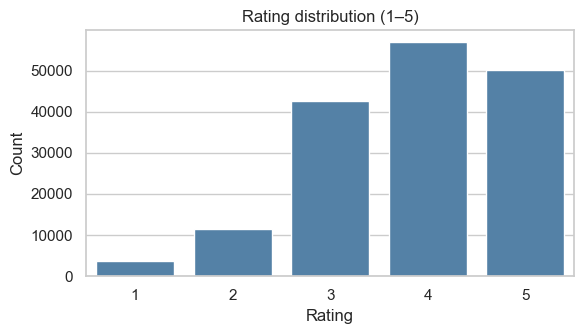

In [3]:
# Distribution of the 1–5 ratings: counts and shares.
rating_counts = ratings["rating"].value_counts().sort_index()
rating_share  = (rating_counts / len(ratings) * 100).round(1)

dist = pd.DataFrame({"count": rating_counts, "pct": rating_share})
print(dist)
print(f"\nMean rating: {ratings['rating'].mean():.2f}  |  "
      f"Median: {ratings['rating'].median():.0f}  |  "
      f"% of ratings ≥ 4 (our 'relevant' threshold): {(ratings['rating'] >= 4).mean()*100:.1f}%")

# Bar plot of the distribution.
plt.figure(figsize=(6, 3.5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="steelblue")
plt.title("Rating distribution (1–5)")
plt.xlabel("Rating"); plt.ylabel("Count")
plt.tight_layout()
plt.show()


Users: 1,192  |  Books rated: 9,229  |  Matrix density: 1.497%

Ratings per USER  — min 100, median 129, max 200
Ratings per BOOK  — min 1, median 8, max 100
Books with only 1 rating: 768  (8.3% of rated books)


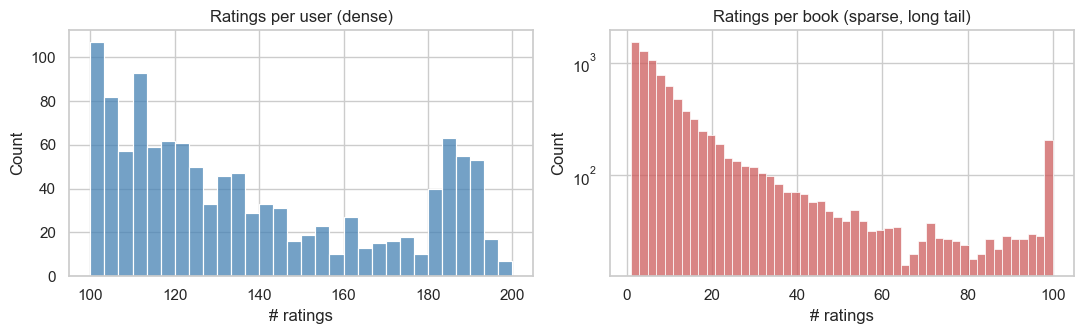

In [4]:
n_users = ratings["user_id"].nunique()
n_books = ratings["book_id"].nunique()
density = len(ratings) / (n_users * n_books)

per_user = ratings.groupby("user_id").size()
per_book = ratings.groupby("book_id").size()

print(f"Users: {n_users:,}  |  Books rated: {n_books:,}  |  "
      f"Matrix density: {density*100:.3f}%")
print(f"\nRatings per USER  — min {per_user.min()}, median {per_user.median():.0f}, max {per_user.max()}")
print(f"Ratings per BOOK  — min {per_book.min()}, median {per_book.median():.0f}, max {per_book.max()}")
print(f"Books with only 1 rating: {(per_book == 1).sum():,}  "
      f"({(per_book == 1).mean()*100:.1f}% of rated books)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(per_user, bins=30, color="steelblue", ax=axes[0])
axes[0].set_title("Ratings per user (dense)"); axes[0].set_xlabel("# ratings")
sns.histplot(per_book, bins=50, color="indianred", ax=axes[1])
axes[1].set_title("Ratings per book (sparse, long tail)"); axes[1].set_xlabel("# ratings")
axes[1].set_yscale("log")  # log scale: the long tail is otherwise invisible
plt.tight_layout()
plt.show()


Most-rated books in our sample:
                                                 title                                            authors  n_ratings  mean_rating
               The Hunger Games (The Hunger Games, #1)                                    Suzanne Collins        100         4.24
                                          The Crucible                  Arthur Miller, Christopher Bigsby        100         3.51
                                   The Grapes of Wrath                                     John Steinbeck        100         3.89
       Anne of Green Gables (Anne of Green Gables, #1)                                    L.M. Montgomery        100         3.96
                                             The Pearl                                     John Steinbeck        100         3.54
                Divine Secrets of the Ya-Ya Sisterhood                                      Rebecca Wells        100         3.58
                                    The Scarlet Letter Nat

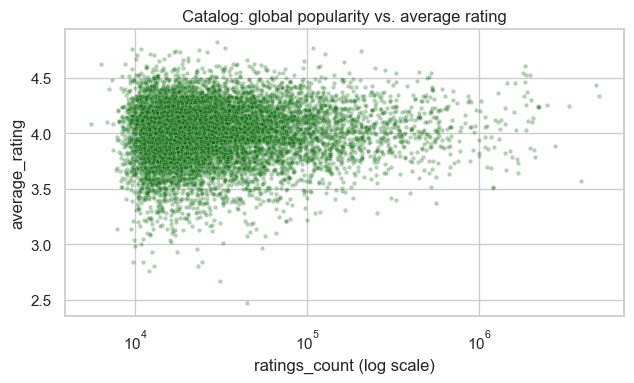


Corr(log ratings_count, average_rating): 0.068


In [5]:
# In-sample popularity: most-rated books among OUR 1,192 users, with our observed mean.
pop_in_sample = (ratings.groupby("book_id")
                 .agg(n_ratings=("rating", "size"), mean_rating=("rating", "mean"))
                 .join(books_by_id[["title", "authors"]])
                 .sort_values("n_ratings", ascending=False))
print("Most-rated books in our sample:")
print(pop_in_sample.head(10)[["title", "authors", "n_ratings", "mean_rating"]]
      .round(2).to_string(index=False))

# Global (Goodreads-wide) popularity vs quality, straight from the catalog columns.
plt.figure(figsize=(6.5, 4))
sns.scatterplot(data=books, x="ratings_count", y="average_rating",
                s=10, alpha=0.3, color="darkgreen")
plt.xscale("log")  # ratings_count spans several orders of magnitude
plt.title("Catalog: global popularity vs. average rating")
plt.xlabel("ratings_count (log scale)"); plt.ylabel("average_rating")
plt.tight_layout()
plt.show()

print(f"\nCorr(log ratings_count, average_rating): "
      f"{np.corrcoef(np.log(books['ratings_count']), books['average_rating'])[0,1]:.3f}")


In [6]:
# 1) Missing values in the columns we rely on.
key_cols = ["authors", "original_publication_year", "average_rating",
            "ratings_count", "language_code", "title"]
print("Missing values by column:")
print(books[key_cols].isna().sum()[lambda s: s > 0].to_string() or "  (none)")

# 2) Language codes are fragmented (same language, many tags).
print("\nTop language codes:")
print(books["language_code"].value_counts(dropna=False).head(8).to_string())

# 3) Publication-year outliers.
yr = books["original_publication_year"]
print(f"\nPublication year — min {yr.min():.0f}, max {yr.max():.0f}, "
      f"missing {yr.isna().sum()}")
print("Oldest 5 'books' by stated year:")
print(books.nsmallest(5, "original_publication_year")[["title", "original_publication_year"]]
      .to_string(index=False))

# 4) Catalog books never rated by ANY of our users → invisible to CF.
rated_ids   = set(ratings["book_id"])
unrated     = books[~books["book_id"].isin(rated_ids)]
print(f"\nBooks in catalog never rated by our users: {len(unrated):,} "
      f"({len(unrated)/len(books)*100:.1f}% of catalog)")


Missing values by column:
original_publication_year      21
language_code                1076

Top language codes:
language_code
eng      6322
en-US    2062
NaN      1076
en-GB     256
ara        64
en-CA      58
fre        25
ind        21

Publication year — min -1750, max 2017, missing 21
Oldest 5 'books' by stated year:
                         title  original_publication_year
         The Epic of Gilgamesh                    -1750.0
         The Iliad/The Odyssey                     -762.0
                     The Iliad                     -750.0
The I Ching or Book of Changes                     -750.0
                   The Odyssey                     -720.0

Books in catalog never rated by our users: 735 (7.4% of catalog)


### EDA takeaways

**Users (the strong side of the matrix)**
- Every user has **100–200 ratings** (median ~129) — unusually dense for a recommender. → User-based CF has rich signal to find similar users; no user cold-start in this sample.

**Ratings / reviews**
- Strong **left skew**: mean ≈ 3.84, median 4, and **~65% of ratings are ≥ 4** (our relevance threshold). → Precision@K will look high for almost any model, so we judge the **baseline-vs-CF gap**, not the absolute score. It also warns that **RMSE rewards "predict high for everyone,"** which is why we also score ranking metrics.

**Books (the weak side)**
- Books are **sparse**: median ~8 ratings, a long tail down to single ratings; overall matrix density ≈ **1.5%**. → Item-based CF and per-book estimates rest on thin evidence; one 5★ can inflate an obscure title. **Motivates the `MIN_RATINGS` popularity filter** before building Top-N lists.
- Popularity is concentrated in recognizable blockbusters that are also highly rated → a **popularity baseline is a genuinely strong benchmark** (popular books are widely liked), but it's identical for every user — **zero personalization**.

**Anomalies / data-quality**
- **Fragmented language codes** (`eng`/`en-US`/`en-GB`) — normalize if ever filtering by language.
- **Publication-year outliers** (BCE classics, some missing) — legitimate but noisy if used as a feature.
- **735 books (~7%) are never rated by our users** — invisible to CF; reachable only via metadata. A concrete CF coverage limit that helps motivate the metadata-aware LLM layer.
- **Two-population caveat:** `average_rating`/`ratings_count` are Goodreads-wide (millions of users); CF learns only from our 1,192-user sample. Don't conflate them.

**Questions this raises for modeling**
1. Can CF beat a strong popularity baseline given this sparsity? (Tested in §2.)
2. What `MIN_RATINGS` cutoff balances coverage vs. evidence?
3. With no genre column, how do we personalize beyond rating prediction? (Addressed by the pseudo-genre + LLM layer in §3.)


## 2. Collaborative-Filtering Model Bake-Off

<small>We compare a **popularity/mean baseline** against user- and item-based collaborative filtering (`surprise`). Models are scored two ways: **RMSE** (rating-prediction accuracy) and **Precision@10 / Recall@10** (Top-N ranking quality). Per the EDA, ranking metrics and the *gap over the baseline* matter more than absolute RMSE.</small>


In [7]:
from surprise import (KNNBasic, BaselineOnly, NormalPredictor,
                      Dataset, Reader, accuracy)
from surprise.model_selection import train_test_split

# Our ratings are integers 1–5 (confirmed in EDA) — declare that scale.
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["user_id", "book_id", "rating"]], reader)

# Hold out 10% for evaluation; same seed -> identical split across all models.
trainset, testset = train_test_split(data, test_size=0.1, random_state=RANDOM_STATE)
print(f"Train: {trainset.n_ratings:,} ratings  |  Test: {len(testset):,} ratings")


Train: 148,255 ratings  |  Test: 16,473 ratings


In [8]:
from collections import defaultdict

def precision_recall_at_k(predictions, top_n=10, threshold=4.0):
    # Group every prediction by user: list of (predicted, actual) pairs.
    user_data = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_data[uid].append((est, true_r))

    precisions, recalls = [], []
    for items in user_data.values():
        items.sort(key=lambda x: x[0], reverse=True)          # rank by predicted rating
        n_relevant = sum(1 for _, t in items if t >= threshold)        # all relevant for this user
        n_hits     = sum(1 for _, t in items[:top_n] if t >= threshold)  # relevant within top-N
        precisions.append(n_hits / top_n)
        if n_relevant > 0:                                    # avoid div-by-zero
            recalls.append(n_hits / n_relevant)

    return np.mean(precisions), np.mean(recalls)


In [9]:
# Four candidates: one baseline + three CF models.
# Baseline = BaselineOnly (μ + user bias + item bias): a mean-based model whose
# per-user ranking is driven by item bias, i.e. a popularity/quality recommender.
# This is the benchmark the collaborative-filtering models must beat.
# k values mirror the Week 3 exercise for continuity.
models = {
    "Baseline":  BaselineOnly(verbose=False),
    "ubcf_cos":  KNNBasic(k=10, sim_options={"name": "cosine",  "user_based": True},  verbose=False),
    "ubcf_pear": KNNBasic(k=50, sim_options={"name": "pearson", "user_based": True},  verbose=False),
    "ibcf":      KNNBasic(k=50, sim_options={"name": "cosine",  "user_based": False}, verbose=False),
}
print(f"{len(models)} candidate models defined: {list(models.keys())}")


4 candidate models defined: ['Baseline', 'ubcf_cos', 'ubcf_pear', 'ibcf']


In [10]:
# In practice you wouldn't hand-pick k and the similarity metric — you'd tune them with
# cross-validation (surprise GridSearchCV/RandomizedSearchCV), scoring the metric you
# actually care about: for a Top-N list that's a ranking metric (Precision@K / NDCG@K),
# not RMSE. Production systems also use time-based splits and confirm the winner via A/B test.
results = []
for name, model in models.items():
    model.fit(trainset)
    preds = model.test(testset)
    rmse = accuracy.rmse(preds, verbose=False)
    p, r = precision_recall_at_k(preds, top_n=10, threshold=4.0)
    results.append({"Model": name, "RMSE": rmse, "Precision@10": p, "Recall@10": r})
    print(f"  done: {name}")

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df


  done: Baseline
  done: ubcf_cos
  done: ubcf_pear
  done: ibcf


,RMSE,Precision@10,Recall@10
Model,,,
Baseline,0.8423,0.6568,0.7912
ubcf_cos,1.0201,0.6493,0.7795
ubcf_pear,1.0268,0.6598,0.7939
ibcf,0.8626,0.6366,0.7684


In [12]:
baseline  = models["Baseline"]
ubcf_pear = models["ubcf_pear"]

# Three valid, spread-out user_ids straight from the data (ids aren't 1..N contiguous).
sample_users = ratings["user_id"].drop_duplicates().sort_values().iloc[[0, 400, 900]].tolist()

for uid in sample_users:
    print(f"\n===== User {uid} =====")
    print("  Baseline:")
    for title, est in top_n_for_user(baseline, uid, top_n=5):
        print(f"    {est:.2f}  {title}")
    print("  UBCF Pearson:")
    for title, est in top_n_for_user(ubcf_pear, uid, top_n=5):
        print(f"    {est:.2f}  {title}")

# Quantitative kicker: books shared by ALL three users' Top-10 (high = not personalized).
def shared_across(model, users, top_n=10):
    lists = [{bid for bid, _ in score_unseen(model, u)[:top_n]} for u in users]
    return len(set.intersection(*lists))

print(f"\nBooks shared by ALL {len(sample_users)} users' Top-10:")
print(f"  Baseline : {shared_across(baseline, sample_users)} / 10")
print(f"  UBCF Pear: {shared_across(ubcf_pear, sample_users)} / 10")



===== User 35 =====
  Baseline:
    3.91  Words of Radiance (The Stormlight Archive, #2)
    3.84  The Name of the Wind (The Kingkiller Chronicle, #1)
    3.78  The Complete Calvin and Hobbes
    3.78  The Complete Novels
    3.75  Night Watch (Discworld, #29; City Watch, #6)
  UBCF Pearson:
    5.00  Perfect Chemistry (Perfect Chemistry, #1)
    5.00  Batman: Year One
    5.00  Poison Study (Study, #1)
    5.00  The Slow Regard of Silent Things (The Kingkiller Chronicle #2.5)
    5.00  Wither (The Chemical Garden, #1)

===== User 15788 =====
  Baseline:
    4.70  Words of Radiance (The Stormlight Archive, #2)
    4.62  The Name of the Wind (The Kingkiller Chronicle, #1)
    4.57  The Complete Calvin and Hobbes
    4.56  The Complete Novels
    4.53  Night Watch (Discworld, #29; City Watch, #6)
  UBCF Pearson:
    5.00  Me Before You (Me Before You, #1)
    5.00  In Cold Blood
    5.00  How to Win Friends and Influence People
    5.00  The Screwtape Letters
    5.00  Harry Potter Boxs

### C) Which model would you deploy?

**Lowest RMSE:** `Baseline` (0.842); `ibcf` close (0.863). User-based KNN is far worse (~1.02) — `KNNBasic` averages *raw* neighbor ratings with no bias term, so under our sparsity and the 4–5 skew its estimates are poorly calibrated.

**Best Top-N ranking:** `ubcf_pear` — highest on Precision@10 (0.660) and Recall@10 (0.794), but only ~0.003 over `Baseline`. So the best-RMSE and best-ranking models differ, and **CF does not meaningfully beat the baseline** on the metrics — the expected result given ~1.5% density and a strong popularity benchmark.

**The deciding factor is personalization** (cell above): across three distinct users, `Baseline` shared **10/10** of its Top-10 — the *identical* list for everyone — while `ubcf_pear` shared **0/10**. The Baseline is a popularity recommender in disguise; `ubcf_pear` produces genuinely user-specific lists.

**Deploy `ubcf_pear`.** RMSE isn't the objective for a Top-N list — ranking is, and it's (marginally) best there. Decisively, it feeds an LLM re-ranking layer whose entire job is personalization, so a candidate pool that already varies per user (0/10 shared vs 10/10) is exactly what's needed. The cost — worse RMSE, heavier compute — is acceptable for an offline retriever.

*(If pure rating prediction or latency/simplicity dominated, `Baseline` would be the right ship. "Best" is task-dependent.)*


In [11]:
# Popularity filter: only books with enough ratings are eligible (EDA-motivated).
# 20 is a reasonable cut for this dataset (2,430 books); the right value depends on
# how much catalog coverage vs. evidence you want.
MIN_RATINGS = 20
counts = ratings["book_id"].value_counts()
popular_books = set(counts[counts >= MIN_RATINGS].index)
print(f"Candidate pool: {len(popular_books):,} of {ratings['book_id'].nunique():,} "
      f"rated books have >= {MIN_RATINGS} ratings")

def score_unseen(model, user_id):
    """Predict a rating for every POPULAR book the user hasn't rated.
    Returns [(book_id, predicted_rating), ...] sorted high -> low. Reused by
    the display Top-N AND the LLM candidate pool, so they never diverge."""
    seen = set(ratings.loc[ratings["user_id"] == user_id, "book_id"])
    candidates = popular_books - seen
    scored = [(bid, model.predict(user_id, bid).est) for bid in candidates]
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored

def top_n_for_user(model, user_id, top_n=10):
    """Display-friendly Top-N: [(title, predicted_rating), ...]."""
    return [(title_of.get(bid, bid), est)
            for bid, est in score_unseen(model, user_id)[:top_n]]


Candidate pool: 2,430 of 9,229 rated books have >= 20 ratings


In [15]:
import json, os, time, re
from google import genai
from google.genai import types

with open(SECRETS_PATH) as f:
    client = genai.Client(api_key=json.load(f)["GOOGLE_API_KEY"])

# All chat-capable models the key serves.
names = [m.name.split("/")[-1] for m in client.models.list()
         if "generateContent" in (m.supported_actions or [])]

def pick_latest(must, avoid=("preview", "exp", "thinking")):
    """Highest-version name containing all `must` tokens and none of `avoid`."""
    cand = [n for n in names if all(t in n for t in must)
            and not any(a in n for a in avoid)]
    ver = lambda n: float(m.group(1)) if (m := re.search(r"(\d+\.\d+)", n)) else 0.0
    return max(cand, key=ver) if cand else None

GEMINI_TAG_MODEL    = pick_latest(["flash", "lite"]) or pick_latest(["flash"])
GEMINI_RERANK_MODEL = pick_latest(["flash"], avoid=("preview", "exp", "thinking", "lite"))
print("tag   :", GEMINI_TAG_MODEL)
print("rerank:", GEMINI_RERANK_MODEL)


tag   : gemini-3.1-flash-lite
rerank: gemini-3.5-flash


### 3a. Deriving genres from Goodreads shelves

<small>Books.csv has no genre column, so we build one from real reader behavior: the Goodbooks-10k companion files record how millions of users **shelved** each book (`fantasy`, `historical-fiction`, …). We join those shelves to our catalog, rank them by usage, and use a single LLM call to canonicalize the messy shelf names into a clean genre vocabulary (merging `sci-fi`/`science-fiction`, dropping non-genre shelves like `to-read`). Each book gets its top-3 genres by usage. The result is cached to `book_genres.csv` and reused everywhere (notebook + Streamlit).</small>


In [18]:
import os, certifi
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

os.environ["SSL_CERT_FILE"] = certifi.where()   # fix macOS "CERTIFICATE_VERIFY_FAILED"



if os.path.exists(GENRES_PATH):
    genres_df = pd.read_csv(GENRES_PATH)
    print(f"Loaded cached genres: {len(genres_df):,} books")
else:
    GB = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/"
    gb_books  = pd.read_csv(GB + "books.csv", usecols=["book_id", "goodreads_book_id"])
    book_tags = pd.read_csv(GB + "book_tags.csv")     # goodreads_book_id, tag_id, count
    gb_tags   = pd.read_csv(GB + "tags.csv")          # tag_id, tag_name

    # Join shelf names and map to OUR book_id (== goodbooks book_id); keep our catalog only.
    bt = (book_tags.merge(gb_tags, on="tag_id")
                   .merge(gb_books, on="goodreads_book_id"))
    bt = bt[bt["book_id"].isin(books["book_id"])]

    # Data-driven vocab: canonicalize the 150 most-used shelves into genres (one LLM call).
    top_shelves = (bt.groupby("tag_name")["count"].sum()
                     .sort_values(ascending=False).head(150).index.tolist())
    prompt = ("These are Goodreads shelf names. Map each to a clean book GENRE in snake_case, "
              "merging synonyms (e.g. sci-fi & science-fiction -> science_fiction). "
              "If a shelf is NOT a genre (to-read, owned, favorites, kindle, series, default, "
              "audiobook, ...), map it to null. Return a JSON object {shelf: genre_or_null}.\n\n"
              f"Shelves: {top_shelves}")
    resp = client.models.generate_content(
        model=GEMINI_RERANK_MODEL, contents=prompt,
        config=types.GenerateContentConfig(temperature=0, response_mime_type="application/json"))
    tag2genre = {k: v for k, v in json.loads(resp.text).items() if v}

    # Per book: keep its genre shelves, ordered by usage, deduped, top 3.
    bt["genre"] = bt["tag_name"].map(tag2genre)
    bt = bt.dropna(subset=["genre"]).sort_values("count", ascending=False)

    def top3(genre_series):
        return "|".join(list(dict.fromkeys(genre_series))[:3])  # keep-order dedup, top 3 by count

    genres_df = bt.groupby("book_id")["genre"].apply(top3).reset_index()
    genres_df.columns = ["book_id", "genres"]
    genres_df.to_csv(GENRES_PATH, index=False)
    print(f"Derived & cached genres for {len(genres_df):,} books -> {GENRES_PATH}")

GENRE_VOCAB = sorted({g for gs in genres_df["genres"].dropna() for g in gs.split("|")})
print(f"Coverage: {len(genres_df):,}/{len(books):,} books | {len(GENRE_VOCAB)} genres")
print(GENRE_VOCAB)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>